In [1]:
import pandas as pd
import numpy as np
 
df = pd.read_csv("sapacr-2005-2026-v1.4.csv")
 
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [2]:
df.head()

,year,station,loc_mn,dc_mn,longitude,latitude,other_theft,arson,assault_gbh,attempted_murder,...,cash_transit_robbery,aggr_robbery,sexual_assault,sexual_offences,police_detected_sexoff,shoplifting,stock_theft,vehicle_theft,theft_from_vehicle,truck_hijacking
0,2005/2006,aberdeen,dr beyers naude,sarah baartman,24.06098,-32.47634,63,0,79,3,...,0,1,0,NaN,0,3,46,0,9,0
1,2006/2007,aberdeen,dr beyers naude,sarah baartman,24.06098,-32.47634,54,0,88,2,...,0,1,0,NaN,0,0,37,0,7,0
2,2007/2008,aberdeen,dr beyers naude,sarah baartman,24.06098,-32.47634,38,0,70,4,...,0,0,3,NaN,0,0,49,4,7,0
3,2008/2009,aberdeen,dr beyers naude,sarah baartman,24.06098,-32.47634,41,0,69,0,...,0,1,3,15.0,0,3,45,0,2,0
4,2009/2010,aberdeen,dr beyers naude,sarah baartman,24.06098,-32.47634,43,2,67,3,...,0,2,1,8.0,0,2,44,1,4,0


In [3]:
df.shape

(24206, 38)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24206 entries, 0 to 24205
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    24206 non-null  str    
 1   station                 24206 non-null  str    
 2   loc_mn                  23730 non-null  str    
 3   dc_mn                   23730 non-null  str    
 4   longitude               23709 non-null  float64
 5   latitude                23709 non-null  float64
 6   other_theft             24206 non-null  int64  
 7   arson                   24206 non-null  int64  
 8   assault_gbh             24206 non-null  int64  
 9   attempted_murder        24206 non-null  int64  
 10  attempted_sexoff        24206 non-null  int64  
 11  bank_robbery            24206 non-null  int64  
 12  burglary_nonres         24206 non-null  int64  
 13  burglary_res            24206 non-null  int64  
 14  carjacking              24206 non-null  int64  
 

In [5]:
missing = df.isnull().sum()
 
missing[missing > 0].sort_values(ascending=False)

sexual_offences    3423
latitude            497
longitude           497
loc_mn              476
dc_mn               476
dtype: int64

In [6]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
 
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})
 
missing_table[missing_table["Missing Values"] > 0].sort_values(
    "Missing Values",
    ascending=False
)

,Missing Values,Percentage
sexual_offences,3423,14.141122
latitude,497,2.053210
longitude,497,2.053210
loc_mn,476,1.966455
dc_mn,476,1.966455


In [7]:
print("Duplicate rows:", df.duplicated().sum())
 
print("Duplicate station-year combinations:",

      df.duplicated(subset=["station", "year"]).sum())
 

Duplicate rows: 0
Duplicate station-year combinations: 0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.duplicated(subset=["station", "year"]).sum()

np.int64(0)

In [10]:
crime_columns = [
    "other_theft",
    "arson",
    "assault_gbh",
    "attempted_murder",
    "attempted_sexoff",
    "bank_robbery",
    "burglary_nonres",
    "burglary_res",
    "carjacking",
    "commercial_crime",
    "common_assault",
    "common_robbery",
    "contact_sexoff",
    "dui",
    "drug_crime",
    "illegal_firearms",
    "kidnapping",
    "malicious_damage",
    "murder",
    "rape",
    "robbery_nonres",
    "robbery_res",
    "cash_transit_robbery",
    "aggr_robbery",
    "sexual_assault",
    "sexual_offences",
    "police_detected_sexoff",
    "shoplifting",
    "stock_theft",
    "vehicle_theft",
    "theft_from_vehicle",
    "truck_hijacking"
]
 
negative_values = {}
 
for column in crime_columns:
    count = (df[column] < 0).sum()
    if count > 0:
        negative_values[column] = count
 
negative_values

{'attempted_sexoff': np.int64(123),
 'contact_sexoff': np.int64(384),
 'rape': np.int64(443),
 'sexual_assault': np.int64(252),
 'theft_from_vehicle': np.int64(1)}

In [11]:
for column in negative_values:
    print(f"\n{column}")
    print(df.loc[df[column] < 0, column].value_counts().sort_index())


attempted_sexoff
attempted_sexoff
-4      1
-3      3
-2     11
-1    108
Name: count, dtype: int64

contact_sexoff
contact_sexoff
-11      1
-8       1
-7       1
-6       2
-5       8
-4      14
-3      30
-2      75
-1     252
Name: count, dtype: int64

rape
rape
-17      1
-14      1
-11      2
-10      1
-9       2
-8       4
-7       5
-6      10
-5      12
-4      16
-3      42
-2      85
-1     262
Name: count, dtype: int64

sexual_assault
sexual_assault
-9      1
-6      1
-5      1
-4      2
-3     14
-2     39
-1    194
Name: count, dtype: int64

theft_from_vehicle
theft_from_vehicle
-1    1
Name: count, dtype: int64


In [12]:
df[crime_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
other_theft,24206.0,281.394117,454.596321,0.0,35.0,111.0,335.0,6803.0
arson,24206.0,4.271462,6.160724,0.0,0.0,2.0,6.0,81.0
assault_gbh,24206.0,159.162356,178.466120,0.0,39.0,98.0,216.0,1984.0
attempted_murder,24206.0,17.172561,28.464845,0.0,2.0,7.0,20.0,482.0
attempted_sexoff,24206.0,2.026894,3.095662,-4.0,0.0,1.0,3.0,45.0
bank_robbery,24206.0,0.027886,0.235830,0.0,0.0,0.0,0.0,9.0
burglary_nonres,24206.0,56.835000,78.261543,0.0,10.0,31.0,73.0,1009.0
burglary_res,24206.0,187.920392,235.162647,0.0,32.0,101.0,252.0,2345.0
carjacking,24206.0,13.349665,31.739203,0.0,0.0,1.0,9.0,554.0
commercial_crime,24206.0,75.513592,165.551500,0.0,3.0,15.0,71.0,2870.0


In [13]:
outlier_summary = {}
 
for column in crime_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[column] < lower_bound) | 
                (df[column] > upper_bound)).sum()
    outlier_summary[column] = outliers
 
outlier_summary

{'other_theft': np.int64(2342),
 'arson': np.int64(1367),
 'assault_gbh': np.int64(1499),
 'attempted_murder': np.int64(2334),
 'attempted_sexoff': np.int64(1446),
 'bank_robbery': np.int64(477),
 'burglary_nonres': np.int64(1654),
 'burglary_res': np.int64(1758),
 'carjacking': np.int64(3751),
 'commercial_crime': np.int64(2848),
 'common_assault': np.int64(2071),
 'common_robbery': np.int64(2382),
 'contact_sexoff': np.int64(711),
 'dui': np.int64(2604),
 'drug_crime': np.int64(2592),
 'illegal_firearms': np.int64(2326),
 'kidnapping': np.int64(1229),
 'malicious_damage': np.int64(2060),
 'murder': np.int64(2071),
 'rape': np.int64(1515),
 'robbery_nonres': np.int64(2099),
 'robbery_res': np.int64(2799),
 'cash_transit_robbery': np.int64(3029),
 'aggr_robbery': np.int64(2730),
 'sexual_assault': np.int64(1649),
 'sexual_offences': np.int64(1105),
 'police_detected_sexoff': np.int64(4646),
 'shoplifting': np.int64(3202),
 'stock_theft': np.int64(1578),
 'vehicle_theft': np.int64(3626)

In [14]:
outlier_table = pd.DataFrame(
    list(outlier_summary.items()),
    columns=["Variable", "Potential Outliers"]
)
 
outlier_table.sort_values(
    "Potential Outliers",
    ascending=False
)

,Variable,Potential Outliers
26,police_detected_sexoff,4646
8,carjacking,3751
29,vehicle_theft,3626
27,shoplifting,3202
22,cash_transit_robbery,3029
30,theft_from_vehicle,2975
9,commercial_crime,2848
21,robbery_res,2799
23,aggr_robbery,2730
13,dui,2604


In [15]:
serious_crime_columns = [
    "murder",
    "attempted_murder",
    "rape",
    "sexual_assault",
    "assault_gbh",
    "kidnapping"
]
 
# Make a copy so we don't accidentally destroy the original raw data
df_model = df.copy()
 
# Negative crime counts are invalid, so treat them as missing
df_model[serious_crime_columns] = (
    df_model[serious_crime_columns]
    .mask(df_model[serious_crime_columns] < 0)
)
 
# Create the serious violent crime score
df_model["serious_violent_crime"] = (
    df_model[serious_crime_columns]
    .sum(axis=1, min_count=6)
)
 
df_model[[
    "station",
    "year",
    "serious_violent_crime"
]].head()

,station,year,serious_violent_crime
0,aberdeen,2005/2006,89.0
1,aberdeen,2006/2007,97.0
2,aberdeen,2007/2008,91.0
3,aberdeen,2008/2009,87.0
4,aberdeen,2009/2010,84.0


In [16]:
df_model["start_year"] = (
    df_model["year"]
    .str[:4]
    .astype(int)
)
 
df_model = df_model.sort_values(
    ["station", "start_year"]
).reset_index(drop=True)

In [17]:
df_model["next_year_score"] = (

    df_model.groupby("station")["serious_violent_crime"]

    .shift(-1)

)
 
df_model["next_year_start"] = (

    df_model.groupby("station")["start_year"]

    .shift(-1)

)
 

In [18]:
df_model["consecutive_year"] = (
    df_model["next_year_start"] == df_model["start_year"] + 1
)
 
df_model["consecutive_year"].value_counts()

consecutive_year
True     22997
False     1209
Name: count, dtype: int64

In [19]:
train_mask = (
    df_model["consecutive_year"] &
    df_model["next_year_score"].notna() &
    df_model["start_year"].between(2005, 2021)
)
 
risk_threshold = df_model.loc[
    train_mask,
    "next_year_score"
].quantile(0.75)
 
print("Higher-risk threshold:", risk_threshold)

Higher-risk threshold: 326.0


In [20]:
df_model["risk_class"] = np.nan
 
valid_target = (
    df_model["consecutive_year"] &
    df_model["next_year_score"].notna()
)
 
df_model.loc[valid_target, "risk_class"] = (
    df_model.loc[valid_target, "next_year_score"] >= risk_threshold
).astype(int)

In [21]:
df_model["risk_class"].value_counts()

risk_class
0.0    16909
1.0     5774
Name: count, dtype: int64

In [22]:
df_model["risk_class"].value_counts(normalize=True) * 100

risk_class
0.0    74.544813
1.0    25.455187
Name: proportion, dtype: float64

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
 
# Keep only observations with a valid target
eda = df_model[df_model["risk_class"].notna()].copy()
 
# Convert risk class into readable labels
eda["risk_label"] = eda["risk_class"].map({
    0: "Lower Risk",
    1: "Higher Risk"
})
 
print("Number of observations for visualisation:", len(eda))

Number of observations for visualisation: 22683


In [24]:
# Import the libraries needed for creating our visualisations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
 
 
# ---------------------------------------------------------
# Define consistent colours for the risk classes
# ---------------------------------------------------------
 
# Green represents lower-risk observations
LOWER_RISK_COLOR = "green"
 
# Red represents higher-risk observations
HIGHER_RISK_COLOR = "red"
 
 
# ---------------------------------------------------------
# Create a dataframe containing only observations
# where the target risk class is available
# ---------------------------------------------------------
 
eda = df_model[df_model["risk_class"].notna()].copy()
 
 
# Convert the numerical risk classes into readable labels
# 0 = Lower Risk
# 1 = Higher Risk
eda["risk_label"] = eda["risk_class"].map({
    0: "Lower Risk",
    1: "Higher Risk"
})
 
 
# Display the number of observations being used
print("Number of observations for visualisation:", len(eda))

Number of observations for visualisation: 22683


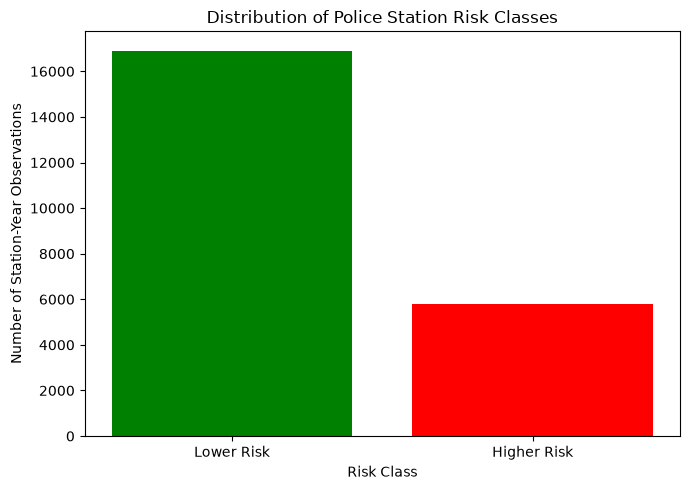

In [25]:
# ---------------------------------------------------------
# VISUALISATION 1
# Distribution of Lower Risk and Higher Risk observations
# ---------------------------------------------------------
 
# Count the number of observations in each risk class
risk_counts = eda["risk_label"].value_counts().reindex(
    ["Lower Risk", "Higher Risk"]
)
 
 
# Create the figure
plt.figure(figsize=(7, 5))
 
 
# Create the bar chart
# Green = Lower Risk
# Red = Higher Risk
plt.bar(
    risk_counts.index,
    risk_counts.values,
    color=[LOWER_RISK_COLOR, HIGHER_RISK_COLOR]
)
 
 
# Add a title
plt.title("Distribution of Police Station Risk Classes")
 
 
# Label the x-axis
plt.xlabel("Risk Class")
 
 
# Label the y-axis
plt.ylabel("Number of Station-Year Observations")
 
 
# Make the layout neat
plt.tight_layout()
 
 
# Display the graph
plt.show()

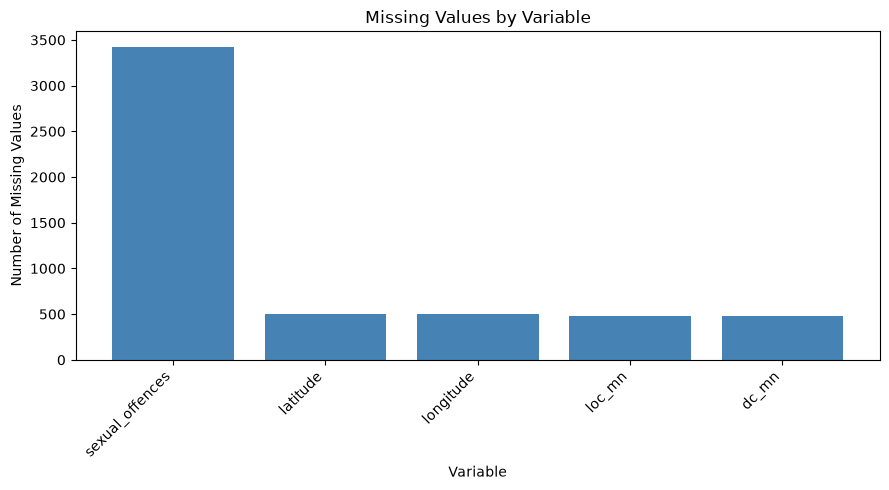

In [26]:
# ---------------------------------------------------------
# VISUALISATION 2
# Missing values in the original dataset
# ---------------------------------------------------------
 
# Count the number of missing values in every variable
missing_counts = df.isna().sum()
 
 
# Keep only variables that actually contain missing values
missing_counts = missing_counts[
    missing_counts > 0
].sort_values(ascending=False)
 
 
# Create the figure
plt.figure(figsize=(9, 5))
 
 
# Create the bar chart
plt.bar(
    missing_counts.index,
    missing_counts.values,
    color="steelblue"
)
 
 
# Add a title
plt.title("Missing Values by Variable")
 
 
# Label the x-axis
plt.xlabel("Variable")
 
 
# Label the y-axis
plt.ylabel("Number of Missing Values")
 
 
# Rotate the variable names so they are easier to read
plt.xticks(rotation=45, ha="right")
 
 
# Make the layout neat
plt.tight_layout()
 
 
# Display the graph
plt.show()

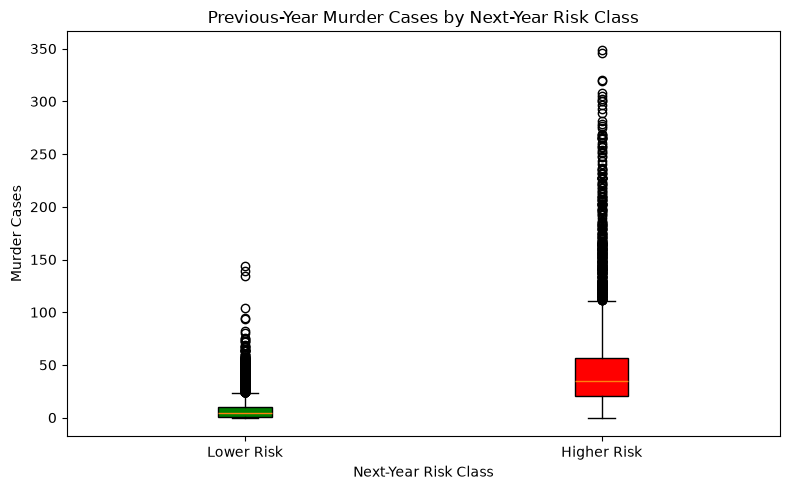

In [27]:
# ---------------------------------------------------------
# VISUALISATION 3
# Previous-year murder cases vs next-year risk class
# ---------------------------------------------------------

# Select murder observations for Lower Risk stations
lower_risk_murder = eda.loc[
    eda["risk_class"] == 0,
    "murder"
].dropna()

# Select murder observations for Higher Risk stations
higher_risk_murder = eda.loc[
    eda["risk_class"] == 1,
    "murder"
].dropna()

# Create the figure
plt.figure(figsize=(8, 5))

# Create the boxplot
box = plt.boxplot(
    [
        lower_risk_murder,
        higher_risk_murder
    ],
    patch_artist=True
)

# Apply the consistent risk colours
box["boxes"][0].set_facecolor(LOWER_RISK_COLOR)   # Green
box["boxes"][1].set_facecolor(HIGHER_RISK_COLOR)  # Red

# Add the risk class labels
plt.xticks(
    [1, 2],
    ["Lower Risk", "Higher Risk"]
)

# Add the title
plt.title("Previous-Year Murder Cases by Next-Year Risk Class")

# Label the x-axis
plt.xlabel("Next-Year Risk Class")

# Label the y-axis
plt.ylabel("Murder Cases")

# Make the layout neat
plt.tight_layout()

# Display the graph
plt.show()

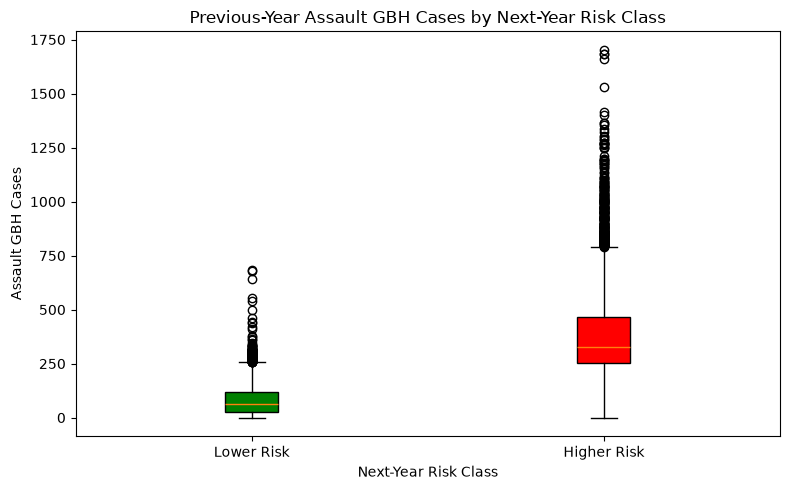

In [28]:
# ---------------------------------------------------------
# VISUALISATION 4
# Previous-year Assault GBH cases vs next-year risk class
# ---------------------------------------------------------

# Create the figure
plt.figure(figsize=(8, 5))

# Select Assault GBH observations for each risk class
box_data = [
    eda.loc[eda["risk_class"] == 0, "assault_gbh"].dropna(),
    eda.loc[eda["risk_class"] == 1, "assault_gbh"].dropna()
]

# Create the boxplot
box = plt.boxplot(
    box_data,
    patch_artist=True
)

# Apply the risk class colours
box["boxes"][0].set_facecolor("green")  # Lower Risk
box["boxes"][1].set_facecolor("red")    # Higher Risk

# Add the risk class labels
plt.xticks(
    [1, 2],
    ["Lower Risk", "Higher Risk"]
)

# Add the title
plt.title("Previous-Year Assault GBH Cases by Next-Year Risk Class")

# Add axis labels
plt.xlabel("Next-Year Risk Class")
plt.ylabel("Assault GBH Cases")

# Make the layout neat
plt.tight_layout()

# Display the graph
plt.show()

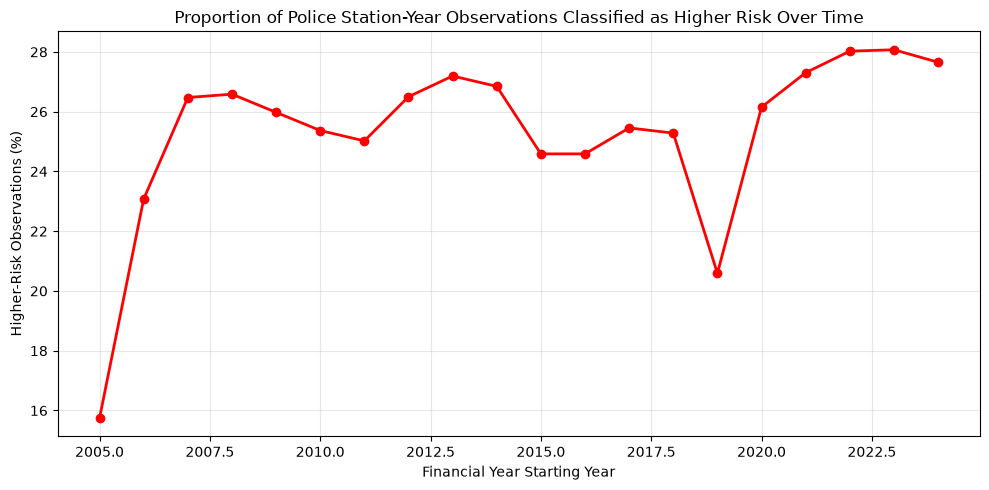

In [29]:
# ---------------------------------------------------------
# VISUALISATION 5
# Proportion of Higher-Risk Police Stations Over Time
# ---------------------------------------------------------

# Calculate the percentage of higher-risk observations per year
yearly_risk = (
    eda.groupby("start_year")["risk_class"]
    .mean()
    .mul(100)
)

# Create the figure
plt.figure(figsize=(10, 5))

# Plot the higher-risk percentage over time in red
plt.plot(
    yearly_risk.index,
    yearly_risk.values,
    marker="o",
    color="red",
    linewidth=2
)

# Add the title
plt.title(
    "Proportion of Police Station-Year Observations "
    "Classified as Higher Risk Over Time"
)

# Label the x-axis
plt.xlabel("Financial Year Starting Year")

# Label the y-axis
plt.ylabel("Higher-Risk Observations (%)")

# Add a grid for readability
plt.grid(True, alpha=0.3)

# Adjust the layout
plt.tight_layout()

# Display the graph
plt.show()

In [30]:
# ---------------------------------------------------------
# Q2.3 - CREATE THE MODELLING DATASET
# ---------------------------------------------------------
 
# Keep only observations where the next-year risk class
# has been successfully calculated.
model_data = df_model[
    df_model["risk_class"].notna()
].copy()
 
 
# Make sure the risk class is stored as an integer
# 0 = Lower Risk
# 1 = Higher Risk
model_data["risk_class"] = model_data["risk_class"].astype(int)
 
 
# Display the number of observations
print("Total modelling observations:", len(model_data))

Total modelling observations: 22683


In [31]:
# ---------------------------------------------------------
# Create chronological train, validation and test sets
# ---------------------------------------------------------
 
# Training data:
# Feature years from 2005 to 2021
train_data = model_data[
    model_data["start_year"].between(2005, 2021)
].copy()
 
 
# Validation data:
# Feature years from 2022 to 2023
validation_data = model_data[
    model_data["start_year"].between(2022, 2023)
].copy()
 
 
# Test data:
# Feature year 2024
test_data = model_data[
    model_data["start_year"] == 2024
].copy()
 
 
# Display the size of each dataset
print("Training observations:", len(train_data))
print("Validation observations:", len(validation_data))
print("Test observations:", len(test_data))

Training observations: 19219
Validation observations: 2296
Test observations: 1168


In [32]:
# ---------------------------------------------------------
# Check class distribution in each dataset
# ---------------------------------------------------------
 
print("\nTraining class distribution:")
print(train_data["risk_class"].value_counts())
print(train_data["risk_class"].value_counts(normalize=True))
 
 
print("\nValidation class distribution:")
print(validation_data["risk_class"].value_counts())
print(validation_data["risk_class"].value_counts(normalize=True))
 
 
print("\nTest class distribution:")
print(test_data["risk_class"].value_counts())
print(test_data["risk_class"].value_counts(normalize=True))


Training class distribution:
risk_class
0    14412
1     4807
Name: count, dtype: int64
risk_class
0    0.749883
1    0.250117
Name: proportion, dtype: float64

Validation class distribution:
risk_class
0    1652
1     644
Name: count, dtype: int64
risk_class
0    0.719512
1    0.280488
Name: proportion, dtype: float64

Test class distribution:
risk_class
0    845
1    323
Name: count, dtype: int64
risk_class
0    0.723459
1    0.276541
Name: proportion, dtype: float64


In [33]:
# ---------------------------------------------------------
# Verify that the chronological split is correct
# ---------------------------------------------------------
 
print("Training years:")
print(
    train_data["start_year"].min(),
    "to",
    train_data["start_year"].max()
)
 
 
print("\nValidation years:")
print(
    validation_data["start_year"].min(),
    "to",
    validation_data["start_year"].max()
)
 
 
print("\nTest years:")
print(
    test_data["start_year"].min(),
    "to",
    test_data["start_year"].max()
)

Training years:
2005 to 2021

Validation years:
2022 to 2023

Test years:
2024 to 2024


In [34]:
# ---------------------------------------------------------
# Q2.4 - STEP 1
# Define the input features and target variable
# ---------------------------------------------------------
 
# ---------------------------------------------------------
# Crime-related predictor variables
# These describe the crime situation during the current
# financial year and will be used to predict the following
# year's risk class.
# ---------------------------------------------------------
 
crime_features = [
    "other_theft",
    "arson",
    "assault_gbh",
    "attempted_murder",
    "attempted_sexoff",
    "bank_robbery",
    "burglary_nonres",
    "burglary_res",
    "carjacking",
    "commercial_crime",
    "common_assault",
    "common_robbery",
    "contact_sexoff",
    "dui",
    "drug_crime",
    "illegal_firearms",
    "kidnapping",
    "malicious_damage",
    "murder",
    "rape",
    "robbery_nonres",
    "robbery_res",
    "cash_transit_robbery",
    "aggr_robbery",
    "sexual_assault",
    "sexual_offences",
    "police_detected_sexoff",
    "shoplifting",
    "stock_theft",
    "vehicle_theft",
    "theft_from_vehicle",
    "truck_hijacking"
]
 
 
# ---------------------------------------------------------
# Geographic and temporal predictor variables
# ---------------------------------------------------------
 
geographic_features = [
    "loc_mn",
    "dc_mn",
    "longitude",
    "latitude",
    "start_year"
]
 
 
# ---------------------------------------------------------
# Combine all predictor variables
# ---------------------------------------------------------
 
feature_columns = crime_features + geographic_features
 
 
# ---------------------------------------------------------
# Define the target variable
# 0 = Lower Risk
# 1 = Higher Risk
# ---------------------------------------------------------
 
target_column = "risk_class"
 
 
# ---------------------------------------------------------
# Display what we have selected
# ---------------------------------------------------------
 
print("Number of crime features:", len(crime_features))
print("Number of geographic/temporal features:", len(geographic_features))
print("Total predictor features:", len(feature_columns))
print("Target variable:", target_column)

Number of crime features: 32
Number of geographic/temporal features: 5
Total predictor features: 37
Target variable: risk_class


In [35]:
# ---------------------------------------------------------
# Create X (input features) and y (target)
# ---------------------------------------------------------
 
# X contains only the variables that the model is allowed
# to use for making its prediction.
X_train = train_data[feature_columns].copy()
X_validation = validation_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()
 
 
# y contains the target we want the model to predict.
y_train = train_data[target_column].copy()
y_validation = validation_data[target_column].copy()
y_test = test_data[target_column].copy()
 
 
# ---------------------------------------------------------
# Check the shapes of the datasets
# ---------------------------------------------------------
 
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
 
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)
 
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (19219, 37)
y_train: (19219,)
X_validation: (2296, 37)
y_validation: (2296,)
X_test: (1168, 37)
y_test: (1168,)


In [36]:
# ---------------------------------------------------------
# Separate numerical and categorical features
# ---------------------------------------------------------
 
# Crime counts, coordinates and year are numerical variables.
numeric_features = crime_features + [
    "longitude",
    "latitude",
    "start_year"
]
 
 
# Municipality variables are categorical.
categorical_features = [
    "loc_mn",
    "dc_mn"
]
 
 
# Display the feature groups
print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))
 
print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 35
Number of categorical features: 2

Categorical features:
['loc_mn', 'dc_mn']


In [37]:
# ---------------------------------------------------------
# Q2.4 - STEP 5A
# Import preprocessing tools
# ---------------------------------------------------------
 
# ColumnTransformer allows us to apply different
# preprocessing steps to different groups of variables.
from sklearn.compose import ColumnTransformer
 
 
# Pipeline allows us to connect multiple preprocessing
# steps together in the correct order.
from sklearn.pipeline import Pipeline
 
 
# SimpleImputer is used to replace missing values.
from sklearn.impute import SimpleImputer
 
 
# StandardScaler standardises numerical variables.
from sklearn.preprocessing import StandardScaler
 
 
# OneHotEncoder converts categorical variables into
# numerical indicator variables.
from sklearn.preprocessing import OneHotEncoder
 
 
# Display confirmation that the imports worked
print("Preprocessing tools imported successfully.")

Preprocessing tools imported successfully.


In [38]:
# ---------------------------------------------------------
# Q2.4 - STEP 5B
# Transformer for invalid negative crime counts
# ---------------------------------------------------------
 
from sklearn.base import BaseEstimator, TransformerMixin
 
 
class NegativeToNaN(BaseEstimator, TransformerMixin):
    """
    Converts negative values in crime-count variables
    into missing values (NaN).
 
    Negative crime counts are treated as invalid values
    and will subsequently be handled by the imputer.
    """
 
    def __init__(self, columns):
        self.columns = columns
 
    def fit(self, X, y=None):
        # No values need to be learned from the data.
        return self
 
    def transform(self, X):
        # Make a copy so that the original dataframe
        # is not modified.
        X = X.copy()
 
        # Replace negative crime counts with NaN.
        X[self.columns] = X[self.columns].mask(
            X[self.columns] < 0
        )
 
        return X

In [39]:
# ---------------------------------------------------------

# Q2.4 - STEP 5C

# Numerical preprocessing pipeline

# ---------------------------------------------------------
 
numeric_pipeline = Pipeline(

    steps=[

        # Step 1:

        # Convert invalid negative crime counts to NaN.

        (

            "negative_to_nan",

            NegativeToNaN(crime_features)

        ),

        # Step 2:

        # Replace missing numerical values with the

        # median calculated from the training data.

        (

            "imputer",

            SimpleImputer(strategy="median")

        ),

        # Step 3:

        # Standardise numerical variables so that they

        # have approximately mean 0 and standard deviation 1.

        (

            "scaler",

            StandardScaler()

        )

    ]

)
 

In [40]:
# ---------------------------------------------------------
# Q2.4 - STEP 5D
# Categorical preprocessing pipeline
# ---------------------------------------------------------
 
categorical_pipeline = Pipeline(
    steps=[
        # Step 1:
        # Replace missing municipality values with the
        # most frequently occurring category.
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        # Step 2:
        # Convert categorical values into numerical
        # one-hot encoded columns.
        #
        # handle_unknown="ignore" ensures that if a category
        # appears in validation/test data but was not present
        # during training, the pipeline will not crash.
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [41]:
# ---------------------------------------------------------
# Q2.4 - STEP 5E
# Combine numerical and categorical preprocessing
# ---------------------------------------------------------
 
preprocessor = ColumnTransformer(
    transformers=[
        # Apply the numerical pipeline to all numerical
        # features.
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        # Apply the categorical pipeline to the
        # categorical features.
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)
 
 
# Display confirmation
print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [42]:
# ---------------------------------------------------------

# Q2.4 - STEP 6A

# Calculate class weights from the training data

# ---------------------------------------------------------
 
from sklearn.utils.class_weight import compute_class_weight
 
 
# Get the two classes present in the training data

classes = np.unique(y_train)
 
 
# Calculate weights based ONLY on the training data.

# This prevents validation/test information from affecting

# the class-balancing procedure.

class_weights = compute_class_weight(

    class_weight="balanced",

    classes=classes,

    y=y_train

)
 
 
# Convert the result into a dictionary.

# The dictionary will map:

# 0 = Lower Risk

# 1 = Higher Risk

class_weight_dict = dict(

    zip(classes, class_weights)

)
 
 
# Display the calculated weights

print("Class weights:")

print(class_weight_dict)
 

Class weights:
{np.int64(0): np.float64(0.6667707466000555), np.int64(1): np.float64(1.9990638651965884)}


In [43]:
# ---------------------------------------------------------
# Verify the class weights
# ---------------------------------------------------------
 
for class_value, weight in class_weight_dict.items():
    # Convert the numerical class into a readable label
    if class_value == 0:
        label = "Lower Risk"
    else:
        label = "Higher Risk"
    print(f"Class {class_value} ({label}): {weight:.3f}")

Class 0 (Lower Risk): 0.667
Class 1 (Higher Risk): 1.999


In [44]:
# ---------------------------------------------------------

# Q2.4 - STEP 7

# Create a reusable modelling pipeline

# ---------------------------------------------------------
 
from sklearn.pipeline import Pipeline
 
 
def create_model_pipeline(model):

    """

    Creates a complete machine-learning pipeline.
 
    The pipeline first performs all preprocessing steps

    and then trains the supplied machine-learning model.

    """
 
    # Combine the preprocessing stage with the model.

    model_pipeline = Pipeline(

        steps=[

            # First, preprocess the input variables.

            (

                "preprocessor",

                preprocessor

            ),

            # Second, train the machine-learning model.

            (

                "model",

                model

            )

        ]

    )
 
    return model_pipeline
 

In [45]:
# ---------------------------------------------------------
# Test the complete preprocessing pipeline
# ---------------------------------------------------------
 
from sklearn.linear_model import LogisticRegression
 
 
# Create a temporary Logistic Regression model
test_model = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42
)
 
 
# Create the complete pipeline
test_pipeline = create_model_pipeline(test_model)
 
 
# Train the pipeline using ONLY the training data
test_pipeline.fit(X_train, y_train)
 
 
# Check validation predictions
validation_predictions = test_pipeline.predict(X_validation)
 
 
# Display confirmation
print("Pipeline test completed successfully.")
print(
    "Number of validation predictions:",
    len(validation_predictions)
)

Pipeline test completed successfully.
Number of validation predictions: 2296


In [46]:
# Install PyTorch for the second neural architecture
#%pip install torch

In [47]:
# ---------------------------------------------------------
# Q6.1 - Define controlled ablation feature sets
# ---------------------------------------------------------
 
# Full feature set used by the final MLP.
full_features = feature_columns.copy()
 
# ---------------------------------------------------------
# Ablation 1:
# Remove all geographic features.
# ---------------------------------------------------------
 
no_geographic_features = [
    feature
    for feature in full_features
    if feature not in [
        "loc_mn",
        "dc_mn",
        "longitude",
        "latitude"
    ]
]
 
# ---------------------------------------------------------
# Ablation 2:
# Remove categorical geographic features only.
# Keep longitude and latitude.
# ---------------------------------------------------------
 
no_categorical_location_features = [
    feature
    for feature in full_features
    if feature not in [
        "loc_mn",
        "dc_mn"
    ]
]
 
# Display the feature counts.
print("Q6.1 Ablation feature sets")
print("--------------------------")
 
print(
    "Full feature count:",
    len(full_features)
)
 
print(
    "Without geographic features:",
    len(no_geographic_features)
)
 
print(
    "Without categorical location features:",
    len(no_categorical_location_features)
)

Q6.1 Ablation feature sets
--------------------------
Full feature count: 37
Without geographic features: 33
Without categorical location features: 35


In [51]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [52]:
# Q6.1 - Ablation 1: Remove all geographic features
#from sklearn.neural_network import MLPClassifier
 
# Features used in this ablation
ablation1_features = no_geographic_features
 
# Define numeric and categorical features
ablation1_numeric_features = [
    feature for feature in numeric_features
    if feature in ablation1_features
]
 
ablation1_categorical_features = [
    feature for feature in categorical_features
    if feature in ablation1_features
]
 
# Numeric preprocessing
ablation1_numeric_pipeline = Pipeline([
    ("negative_to_nan", NegativeToNaN(crime_features)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
 
# Categorical preprocessing
ablation1_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
 
# Combine preprocessing
ablation1_preprocessor = ColumnTransformer([
    ("num", ablation1_numeric_pipeline, ablation1_numeric_features),
    ("cat", ablation1_categorical_pipeline, ablation1_categorical_features)
])
 
# Same MLP architecture and random seed as the original champion
ablation1_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=100,
    batch_size=32,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)
 
# Build pipeline
ablation1_pipeline = Pipeline([
    ("preprocessor", ablation1_preprocessor),
    ("model", ablation1_model)
])
 
# Train only on the training data
ablation1_pipeline.fit(
    X_train[ablation1_features],
    y_train
)
 
# Evaluate on the SAME validation set
ablation1_predictions = ablation1_pipeline.predict(
    X_validation[ablation1_features]
)
 
# Calculate metrics
ablation1_accuracy = accuracy_score(y_validation, ablation1_predictions)
ablation1_precision = precision_score(y_validation, ablation1_predictions)
ablation1_recall = recall_score(y_validation, ablation1_predictions)
ablation1_f1 = f1_score(y_validation, ablation1_predictions, average="macro")
 
print("Q6.1 - Ablation 1: Without Geographic Features")
print("-----------------------------------------------")
print(f"Accuracy:  {ablation1_accuracy:.4f}")
print(f"Precision: {ablation1_precision:.4f}")
print(f"Recall:    {ablation1_recall:.4f}")
print(f"Macro-F1:  {ablation1_f1:.4f}")

Q6.1 - Ablation 1: Without Geographic Features
-----------------------------------------------
Accuracy:  0.9634
Precision: 0.9242
Recall:    0.9472
Macro-F1:  0.9550


In [53]:
# Q6.1 - Ablation 2: Remove categorical location features only
 
# Features used in this ablation
ablation2_features = no_categorical_location_features
 
# Define numeric and categorical features
ablation2_numeric_features = [
    feature for feature in numeric_features
    if feature in ablation2_features
]
 
ablation2_categorical_features = [
    feature for feature in categorical_features
    if feature in ablation2_features
]
 
# Numeric preprocessing
ablation2_numeric_pipeline = Pipeline([
    ("negative_to_nan", NegativeToNaN(crime_features)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
 
# Build preprocessing
ablation2_preprocessor = ColumnTransformer([
    ("num", ablation2_numeric_pipeline, ablation2_numeric_features)
])
 
# Same MLP architecture and random seed
ablation2_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=100,
    batch_size=32,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)
 
# Build pipeline
ablation2_pipeline = Pipeline([
    ("preprocessor", ablation2_preprocessor),
    ("model", ablation2_model)
])
 
# Train on the SAME training data
ablation2_pipeline.fit(
    X_train[ablation2_features],
    y_train
)
 
# Evaluate on the SAME validation set
ablation2_predictions = ablation2_pipeline.predict(
    X_validation[ablation2_features]
)
 
# Calculate metrics
ablation2_accuracy = accuracy_score(
    y_validation, ablation2_predictions
)
 
ablation2_precision = precision_score(
    y_validation, ablation2_predictions
)
 
ablation2_recall = recall_score(
    y_validation, ablation2_predictions
)
 
ablation2_f1 = f1_score(
    y_validation, ablation2_predictions, average="macro"
)
 
print("Q6.1 - Ablation 2: Without Categorical Location Features")
print("---------------------------------------------------------")
print(f"Accuracy:  {ablation2_accuracy:.4f}")
print(f"Precision: {ablation2_precision:.4f}")
print(f"Recall:    {ablation2_recall:.4f}")
print(f"Macro-F1:  {ablation2_f1:.4f}")

Q6.1 - Ablation 2: Without Categorical Location Features
---------------------------------------------------------
Accuracy:  0.9678
Precision: 0.9398
Recall:    0.9457
Macro-F1:  0.9602


In [54]:
# Q6.1 - Ablation 3: Remove StandardScaler
 
# Use the FULL feature set
ablation3_features = full_features
 
# Numeric preprocessing WITHOUT StandardScaler
ablation3_numeric_pipeline = Pipeline([
    ("negative_to_nan", NegativeToNaN(crime_features)),
    ("imputer", SimpleImputer(strategy="median"))
])
 
# Categorical preprocessing stays the same
ablation3_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
 
# Combine preprocessing
ablation3_preprocessor = ColumnTransformer([
    ("num", ablation3_numeric_pipeline, numeric_features),
    ("cat", ablation3_categorical_pipeline, categorical_features)
])
 
# Same MLP architecture and random seed
ablation3_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=100,
    batch_size=32,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)
 
# Build pipeline
ablation3_pipeline = Pipeline([
    ("preprocessor", ablation3_preprocessor),
    ("model", ablation3_model)
])
 
# Train on the SAME training data
ablation3_pipeline.fit(
    X_train[ablation3_features],
    y_train
)
 
# Evaluate on the SAME validation set
ablation3_predictions = ablation3_pipeline.predict(
    X_validation[ablation3_features]
)
 
# Calculate metrics
ablation3_accuracy = accuracy_score(
    y_validation, ablation3_predictions
)
 
ablation3_precision = precision_score(
    y_validation, ablation3_predictions
)
 
ablation3_recall = recall_score(
    y_validation, ablation3_predictions
)
 
ablation3_f1 = f1_score(
    y_validation,
    ablation3_predictions,
    average="macro"
)
 
print("Q6.1 - Ablation 3: Without StandardScaler")
print("-------------------------------------------")
print(f"Accuracy:  {ablation3_accuracy:.4f}")
print(f"Precision: {ablation3_precision:.4f}")
print(f"Recall:    {ablation3_recall:.4f}")
print(f"Macro-F1:  {ablation3_f1:.4f}")

Q6.1 - Ablation 3: Without StandardScaler
-------------------------------------------
Accuracy:  0.9678
Precision: 0.9481
Recall:    0.9363
Macro-F1:  0.9599


In [55]:
# Q6.1 - Ablation results summary
 
ablation_results = pd.DataFrame({
    "Experiment": [
        "Original MLP",
        "Without Geographic Features",
        "Without Categorical Location",
        "Without StandardScaler"
    ],
    "Accuracy": [
        0.9713,
        ablation1_accuracy,
        ablation2_accuracy,
        ablation3_accuracy
    ],
    "Precision": [
        0.9474,
        ablation1_precision,
        ablation2_precision,
        ablation3_precision
    ],
    "Recall": [
        0.9503,
        ablation1_recall,
        ablation2_recall,
        ablation3_recall
    ],
    "Macro-F1": [
        0.9644,
        ablation1_f1,
        ablation2_f1,
        ablation3_f1
    ]
})
 
# Calculate change in Macro-F1 relative to the original MLP
ablation_results["Macro-F1 Change"] = (
    ablation_results["Macro-F1"] - ablation_results.loc[0, "Macro-F1"]
)
 
ablation_results

,Experiment,Accuracy,Precision,Recall,Macro-F1,Macro-F1 Change
0,Original MLP,0.971300,0.947400,0.950300,0.964400,0.000000
1,Without Geographic Features,0.963415,0.924242,0.947205,0.955018,-0.009382
2,Without Categorical Location,0.967770,0.939815,0.945652,0.960150,-0.004250
3,Without StandardScaler,0.967770,0.948113,0.936335,0.959922,-0.004478


<function matplotlib.pyplot.show(close=None, block=None)>

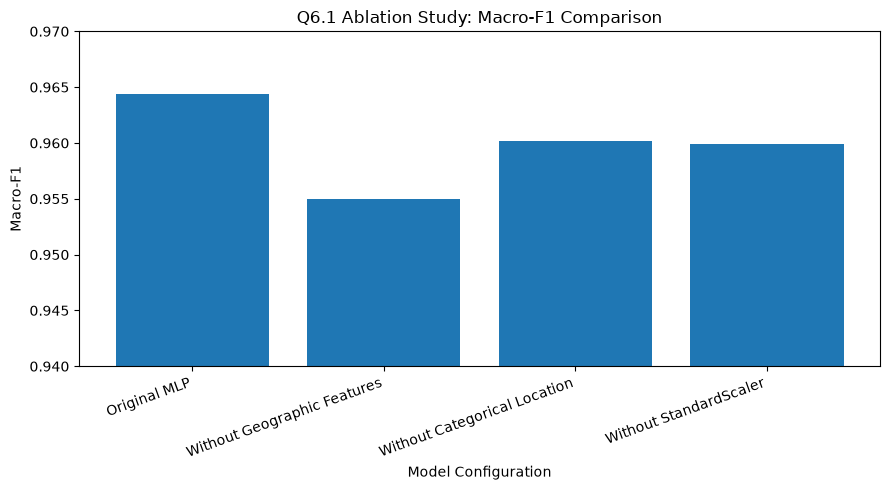

In [56]:
import matplotlib.pyplot as plt
 
plt.figure(figsize=(9, 5))
 
plt.bar(
    ablation_results["Experiment"],
    ablation_results["Macro-F1"]
)
 
plt.title("Q6.1 Ablation Study: Macro-F1 Comparison")
plt.xlabel("Model Configuration")
plt.ylabel("Macro-F1")
plt.ylim(0.94, 0.97)
plt.xticks(rotation=20, ha="right")
 
plt.tight_layout()
plt.show

In [60]:
# Q6.2 - Recreate the preprocessing used by the original MLP
 
neural_numeric_pipeline = Pipeline([
    ("negative_to_nan", NegativeToNaN(crime_features)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
 
neural_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
 
neural_preprocessor = ColumnTransformer([
    ("num", neural_numeric_pipeline, numeric_features),
    ("cat", neural_categorical_pipeline, categorical_features)
])
 
print("Neural preprocessing recreated successfully.")

Neural preprocessing recreated successfully.


In [64]:
# Q6.2 - Recreate the Random Forest comparator

from sklearn.ensemble import RandomForestClassifier
 
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
 
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", random_forest_model)
])
 
# Fit on the training data
random_forest_pipeline.fit(
    X_train[feature_columns],
    y_train
)
 
# Check validation performance first
rf_validation_predictions = random_forest_pipeline.predict(
    X_validation[feature_columns]
)
 
rf_validation_f1 = f1_score(
    y_validation,
    rf_validation_predictions,
    average="macro"
)
 
print("Random Forest validation Macro-F1:", round(rf_validation_f1, 4))

Random Forest validation Macro-F1: 0.9582


In [65]:
# Q6.2 - Generate paired predictions on the same test cases
 
# Champion MLP predictions
champion_test_predictions = champion_pipeline.predict(
    X_test[feature_columns]
)
 
# Random Forest comparator predictions
comparator_test_predictions = random_forest_pipeline.predict(
    X_test[feature_columns]
)
 
print("Q6.2 - Paired Test Predictions")
print("------------------------------")
print("Number of test cases:", len(y_test))
print("Champion predictions:", len(champion_test_predictions))
print("Comparator predictions:", len(comparator_test_predictions))

Q6.2 - Paired Test Predictions
------------------------------
Number of test cases: 1168
Champion predictions: 1168
Comparator predictions: 1168


In [66]:
# Q6.2 - McNemar 2x2 correctness table
 
# Check whether each model was correct for each test case
champion_correct = champion_test_predictions == y_test
comparator_correct = comparator_test_predictions == y_test
 
# Count the four possible outcomes
both_correct = (
    champion_correct & comparator_correct
).sum()
 
champion_only_correct = (
    champion_correct & ~comparator_correct
).sum()
 
comparator_only_correct = (
    ~champion_correct & comparator_correct
).sum()
 
both_wrong = (
    ~champion_correct & ~comparator_correct
).sum()
 
# Create the 2x2 table
mcnemar_table = pd.DataFrame(
    [
        [both_correct, champion_only_correct],
        [comparator_only_correct, both_wrong]
    ],
    index=["MLP Correct", "MLP Wrong"],
    columns=["Random Forest Correct", "Random Forest Wrong"]
)
 
print("Q6.2 - McNemar 2x2 Correctness Table")
print("--------------------------------------")
display(mcnemar_table)
 
print("\nTotal cases:", mcnemar_table.values.sum())
print("Discordant cases:", champion_only_correct + comparator_only_correct)

Q6.2 - McNemar 2x2 Correctness Table
--------------------------------------


,Random Forest Correct,Random Forest Wrong
MLP Correct,1123,11
MLP Wrong,11,23



Total cases: 1168
Discordant cases: 22


In [68]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 212.2 kB/s eta 0:00:51
   - -------------------------------------- 0.5/11.3 MB 212.2 kB/s eta 0:00:51
   - -------------------------------------- 0.5/11.3 MB 212.2 kB/s eta 0

In [69]:
# Q6.2 - McNemar's exact test
 
from statsmodels.stats.contingency_tables import mcnemar
 
# Run exact McNemar test
mcnemar_result = mcnemar(
    mcnemar_table.values,
    exact=True,
    correction=False
)
 
# Significance level
alpha = 0.05
 
print("Q6.2 - McNemar's Exact Test")
print("---------------------------")
print("Test statistic:", mcnemar_result.statistic)
print("Exact p-value:", mcnemar_result.pvalue)
print("Alpha:", alpha)
 
if mcnemar_result.pvalue < alpha:
    print("Decision: Reject H0")
    print("Conclusion: There is a statistically significant difference between the models.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: There is no statistically significant difference between the models.")

Q6.2 - McNemar's Exact Test
---------------------------
Test statistic: 11.0
Exact p-value: 1.0
Alpha: 0.05
Decision: Fail to reject H0
Conclusion: There is no statistically significant difference between the models.


In [70]:
# Q7.1 - Save the final MLP pipeline
 
import joblib
 
# Save the complete fitted pipeline
joblib.dump(
    champion_pipeline,
    "final_mlp_pipeline.joblib"
)
 
print("Final MLP pipeline saved successfully.")
print("File: final_mlp_pipeline.joblib")

Final MLP pipeline saved successfully.
File: final_mlp_pipeline.joblib


In [71]:
# Q7.1 - Verify the saved pipeline
 
import joblib
 
# Load the saved pipeline
loaded_pipeline = joblib.load("final_mlp_pipeline.joblib")
 
# Make predictions using the loaded pipeline
loaded_test_predictions = loaded_pipeline.predict(
    X_test[feature_columns]
)
 
# Check whether loaded predictions match the original champion predictions
predictions_match = (
    loaded_test_predictions == champion_test_predictions
).all()
 
print("Saved pipeline loaded successfully.")
print("Predictions match original pipeline:", predictions_match)

Saved pipeline loaded successfully.
Predictions match original pipeline: True


In [72]:
print("Crime features:")
for feature in crime_features:
    print(feature)
 
print("\nTotal crime features:", len(crime_features))

Crime features:
other_theft
arson
assault_gbh
attempted_murder
attempted_sexoff
bank_robbery
burglary_nonres
burglary_res
carjacking
commercial_crime
common_assault
common_robbery
contact_sexoff
dui
drug_crime
illegal_firearms
kidnapping
malicious_damage
murder
rape
robbery_nonres
robbery_res
cash_transit_robbery
aggr_robbery
sexual_assault
sexual_offences
police_detected_sexoff
shoplifting
stock_theft
vehicle_theft
theft_from_vehicle
truck_hijacking

Total crime features: 32


In [73]:
# Q7.1 - Import the transformer from transformers.py
 
from transformers import NegativeToNaN
 
print("NegativeToNaN imported successfully.")

NegativeToNaN imported successfully.


In [74]:
# Q7.1 - Rebuild the final MLP pipeline using transformers.py
 
import joblib
 
# Recreate the numeric preprocessing using the imported transformer
neural_numeric_pipeline = Pipeline([
    ("negative_to_nan", NegativeToNaN(crime_features)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
 
# Recreate categorical preprocessing
neural_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
 
# Recreate the complete preprocessor
neural_preprocessor = ColumnTransformer([
    ("num", neural_numeric_pipeline, numeric_features),
    ("cat", neural_categorical_pipeline, categorical_features)
])
 
# Recreate the final MLP champion
final_mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=100,
    batch_size=32,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)
 
# Create the complete pipeline
final_mlp_pipeline = Pipeline([
    ("preprocessor", neural_preprocessor),
    ("model", final_mlp_model)
])
 
# Fit using the same training data
final_mlp_pipeline.fit(
    X_train[feature_columns],
    y_train
)
 
# Save the pipeline
joblib.dump(
    final_mlp_pipeline,
    "final_mlp_pipeline.joblib"
)
 
print("Final MLP pipeline rebuilt and saved successfully.")
print("File: final_mlp_pipeline.joblib")

Final MLP pipeline rebuilt and saved successfully.
File: final_mlp_pipeline.joblib


In [75]:
# Q7.1 - Test loading the newly saved pipeline
 
import joblib
 
# Load the newly saved pipeline
test_pipeline = joblib.load("final_mlp_pipeline.joblib")
 
print("Pipeline loaded successfully!")

Pipeline loaded successfully!
